# ML Assignment 1 — Bike Sharing Demand Prediction

## Import Neccessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
sns.set_style("whitegrid")
pd.set_option("display.width", 120)
np.random.seed(42)
import warnings; warnings.filterwarnings("ignore")

In [2]:
# Import Train and Test Datasets
df_train =  pd.read_csv(r"C:\Users\WIN-10\Downloads\files\bike_train.csv")
df_test = pd.read_csv(r"C:\Users\WIN-10\Downloads\files\bike_test.csv")

## Exploratory Data Analysis (EDA)

In [3]:
df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


In [4]:
df_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [5]:
print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

Train Shape:  (10450, 12)
Test Shape:  (2613, 9)


In [6]:
print("Missing Values in train: ", df_train.isna().sum())
print("\nMissing values in test: ", df_test.isna().sum())

Missing Values in train:  datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Missing values in test:  datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


In [7]:
print("Duplicate values in train: ", df_train.duplicated().sum())
print("Duplicate values in test: ", df_test.duplicated().sum())

Duplicate values in train:  0
Duplicate values in test:  0


In [8]:
df_train.dtypes

datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000


In [10]:
print("\nseason value counts (train):\n", df_train['season'].value_counts().sort_index())
print("\nweather value counts (train):\n", df_train['weather'].value_counts().sort_index())
print("\nweather value counts (test):\n", df_test['weather'].value_counts().sort_index())
print("\n(weather=4, 'heavy rain/snow/fog', appears only once in train and not at all in")


season value counts (train):
 season
1    2582
2    2608
3    2630
4    2630
Name: count, dtype: int64

weather value counts (train):
 weather
1    6945
2    2686
3     818
4       1
Name: count, dtype: int64

weather value counts (test):
 weather
1    1683
2     718
3     212
Name: count, dtype: int64

(weather=4, 'heavy rain/snow/fog', appears only once in train and not at all in


---------------------------------------------------------------------------------
Q1 (Answer): Train has 10,450 rows × 12 columns, test has 2,613 rows × 9 columns (test naturally omits casual, registered, count — the columns we must predict). There are no missing values in either file and no duplicate rows in train. All features are numeric already (season, holiday, workingday, weather are integer-coded categoricals; temp, atemp, humidity, windspeed are continuous), except datetime, which is a string and needs parsing — and train/test use two different date formats, which is an easy trap if you parse both the same way. weather=4 (heavy rain/snow) is extremely rare (1 row in train, 0 in test), so it contributes almost no signal and one-hot encoding it can create a near-constant column.

------------------------------------------------------------------------------

## Q2: Visualizing relationships between features and `count`

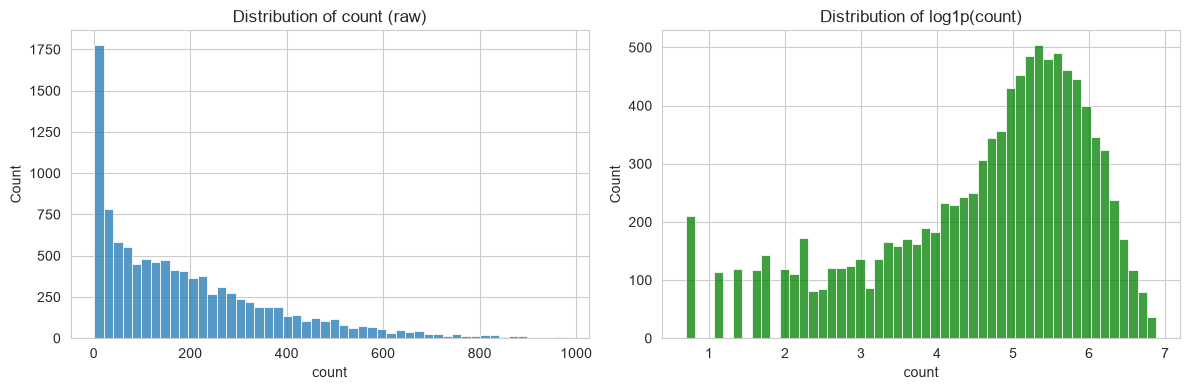

In [11]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
sns.histplot(df_train['count'], bins = 50, ax = axes[0])
axes[0].set_title("Distribution of count (raw)")
sns.histplot(np.log1p(df_train['count']), bins = 50, ax = axes[1], color = 'green')
axes[1].set_title("Distribution of log1p(count)")
plt.tight_layout()
plt.show()

datetime needs separate parsing: train and test use DIFFERENT formats
Next step converts the raw datetime column into useful numerical features that a regression model can understand, especially the time-of-day and seasonal patterns in bike demand.


In [12]:
df_train['hour'] = pd.to_datetime(df_train['datetime'], format = "%Y-%m-%d %H:%M:%S").dt.hour
df_train['weekday'] = pd.to_datetime(df_train['datetime'], format = "%Y-%m-%d %H:%M:%S").dt.weekday
df_train['month'] = pd.to_datetime(df_train['datetime'], format = "%Y-%m-%d %H:%M:%S").dt.month
df_train['year'] = pd.to_datetime(df_train['datetime'], format = "%Y-%m-%d %H:%M:%S").dt.year

Text(0.5, 1.0, 'Mean count by weekday')

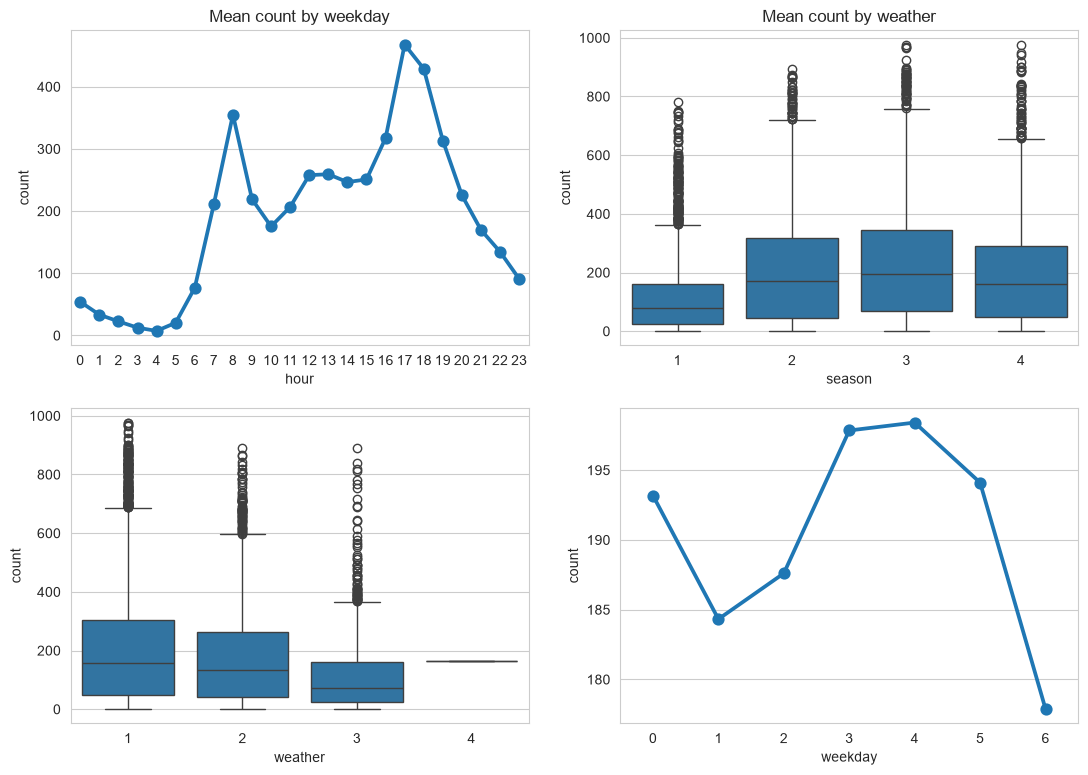

In [13]:
fig, axes = plt.subplots(2,2, figsize = (13,9))

sns.pointplot(data = df_train, x = 'hour', y = 'count', ax = axes[0,0], errorbar = None)
axes[0, 0].set_title("Mean count by hour of day")

sns.boxplot(data = df_train, x = 'season', y = 'count', ax = axes[0,1])
axes[0, 1].set_title("Mean count by season")

sns.boxplot(data = df_train, x = 'weather', y = 'count', ax = axes[1,0])
axes[0, 1].set_title("Mean count by weather")

sns.pointplot(data = df_train, x = 'weekday', y = 'count', ax = axes[1,1], errorbar = None)
axes[0, 0].set_title("Mean count by weekday")

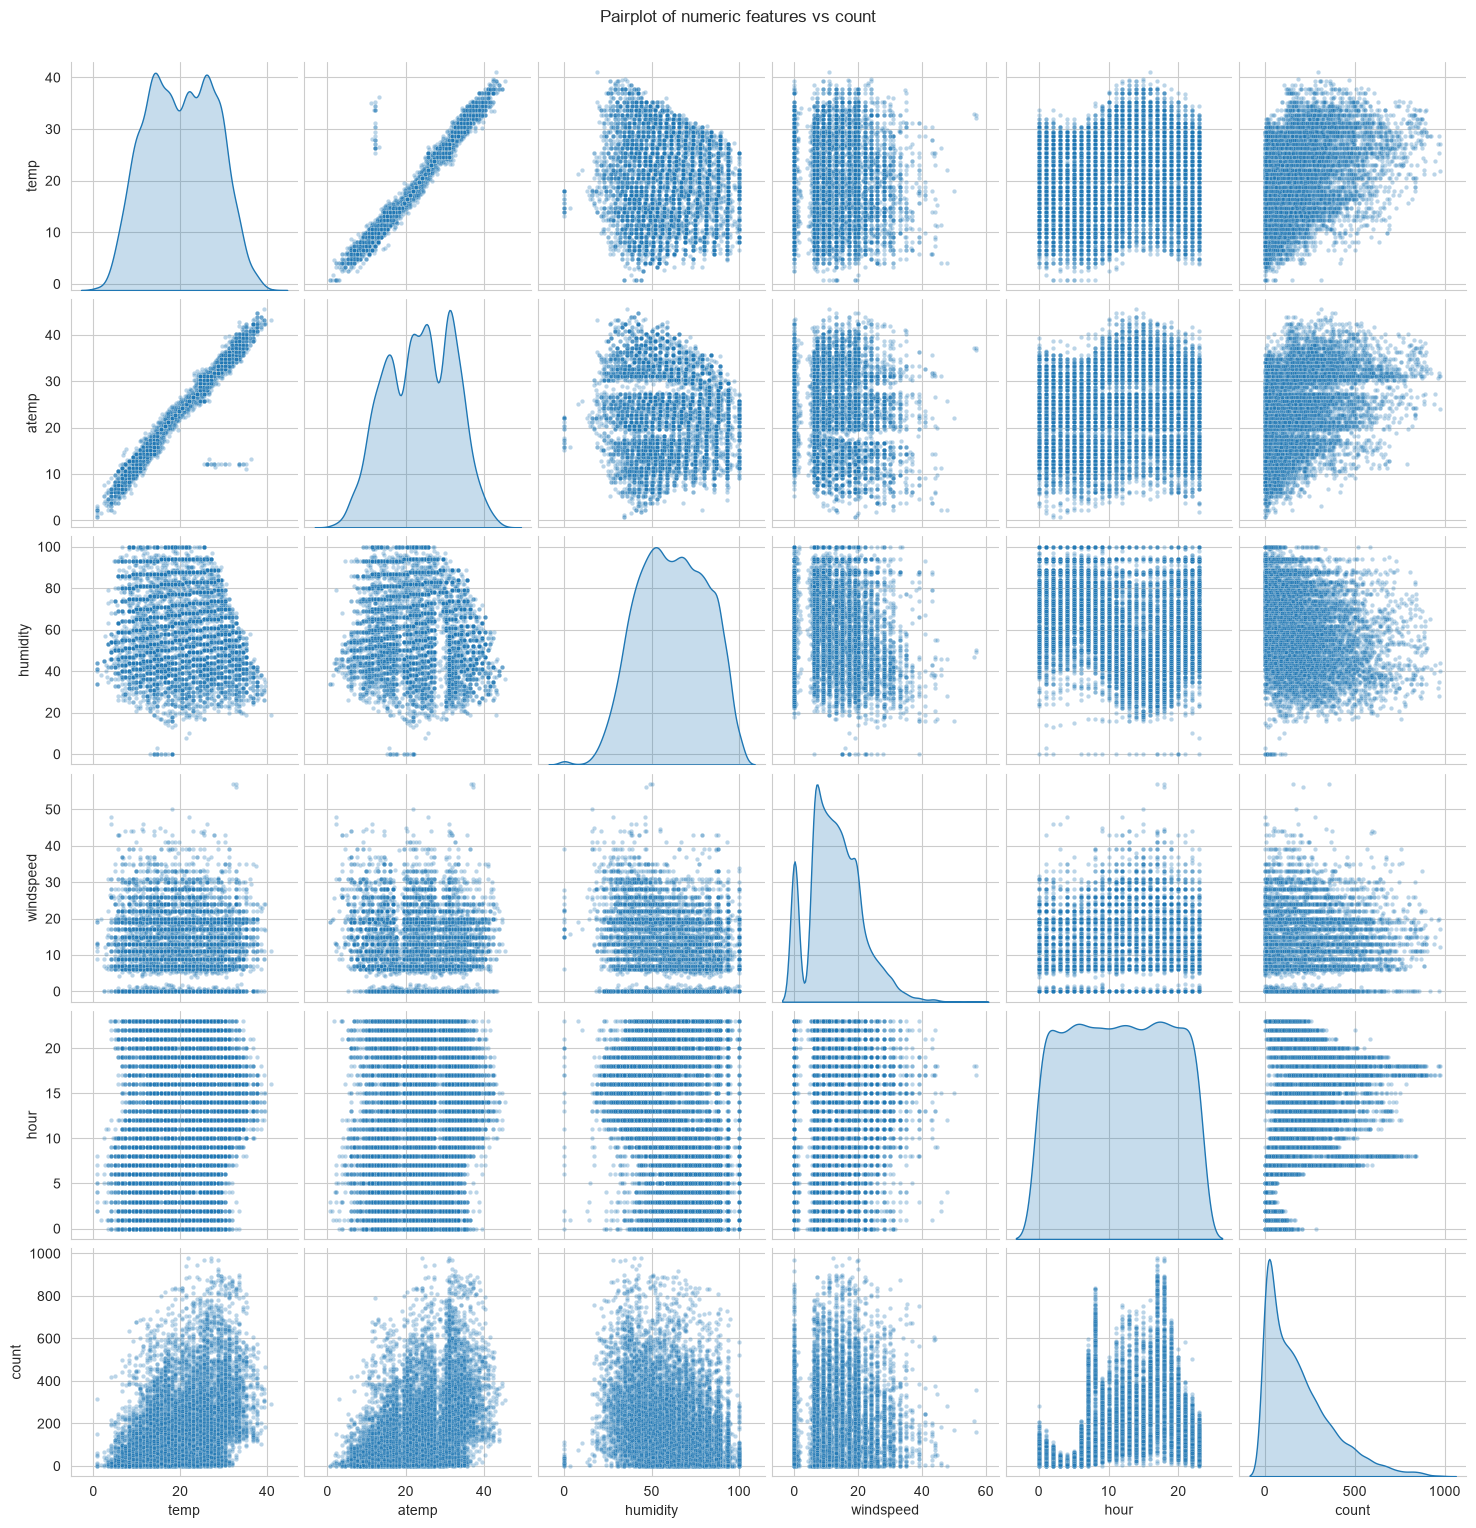

In [40]:
pairplot_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'hour', 'count']
sns.pairplot(df_train[pairplot_cols], diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot of numeric features vs count', y=1.02)
plt.show()


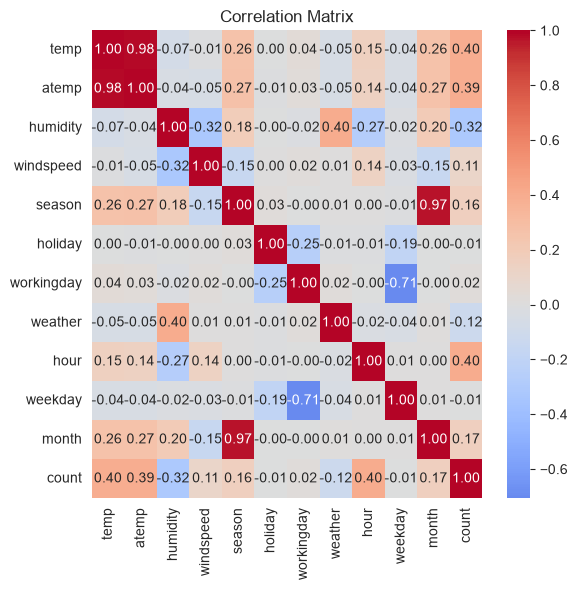

In [14]:
num_cols = ['temp','atemp','humidity','windspeed','season','holiday',
            'workingday','weather','hour','weekday','month','count']
corr = df_train[num_cols].corr()

plt.figure(figsize = (6,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center = 0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
print("Correlation Matrix with count")
print(corr['count'].drop('count').sort_values(ascending = False))

Correlation Matrix with count
hour          0.404188
temp          0.396451
atemp         0.390642
month         0.165475
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
weekday      -0.006489
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


Q2 (Answer): **count** is heavily right-skewed with a long tail — log1p(count) is far closer to symmetric, which is why the models below are trained on the log-target. hour shows a strong bimodal commuting pattern (peaks around 8am and 5–6pm on workdays), which a raw linear hour feature cannot represent (see Q12). temp/atemp correlate positively with count; humidity correlates negatively; windspeed and holiday are weak. weather shows a clear negative trend (worse weather → fewer rentals).

## Q3: Suggest which variables are likely to be most informative
Based on the correlations and plots above, `hour`, `temp`/`atemp`, `humidity`, `workingday`,
`season`, and `weather` all carry real signal. `windspeed` and `holiday` are
the weakest individually but are cheap to keep since regularized models can
shrink them if unhelpful. `atemp` and `temp` are highly collinear with each
other.

## Q4: Feature Engineering

In [16]:
df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,weekday,month,year
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47,7,6,7,2012
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283,15,1,8,2012
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1,6,6,2,2011
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531,17,6,5,2012
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5,2,0,1,2012


In [17]:
df_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [18]:
#Feature Engineering
df_train['year'] = pd.to_datetime(df_train['datetime'], format = "%Y-%m-%d %H:%M:%S").dt.year

df_test['hour'] = pd.to_datetime(df_test['datetime'], format = "%d-%m-%Y %H:%M").dt.hour
df_test['weekday'] = pd.to_datetime(df_test['datetime'], format = "%d-%m-%Y %H:%M").dt.weekday
df_test['month'] = pd.to_datetime(df_test['datetime'], format = "%d-%m-%Y %H:%M").dt.month
df_test['year'] = pd.to_datetime(df_test['datetime'], format = "%d-%m-%Y %H:%M").dt.year

print("New columns added to train:", ['hour','weekday','month','year'])
print("New columns added to test :", ['hour','weekday','month','year'])

New columns added to train: ['hour', 'weekday', 'month', 'year']
New columns added to test : ['hour', 'weekday', 'month', 'year']


One Hot Encoding

In [19]:
# One-hot encode season & weather. Combine train+test first so both end up
# with the SAME dummy columns (important — otherwise Ridge/Lasso breaks when
# predicting on test if a category is missing from one side).

df_train['is_train'] = 1
df_test['is_train'] = 0
combined = pd.concat([df_train, df_test], sort = False)

combined = pd.get_dummies(combined, columns = ['season', 'weather'], prefix = ['season', 'weather'])

df_train = combined[combined['is_train'] == 1].drop(columns = ['is_train'])
df_test = combined[combined['is_train'] == 0].drop(columns = ['is_train'])

print("Train shape after dummies: ", df_train.shape)
print("Test shape after dummies: ", df_test.shape)

Train shape after dummies:  (10450, 22)
Test shape after dummies:  (2613, 22)


## Q5. Train and Test Split + Linear Regression Model

In [20]:
feature_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'hour', 'weekday',
                'month', 'year', 'holiday', 'workingday'] + \
                [c for c in df_train.columns if c.startswith("season_") or c.startswith("weather_")]

x = df_train[feature_cols]
y_count = df_train['count'].values
y_log = np.log1p(y_count)

x_test_final = df_test[feature_cols]

print("Features used:", feature_cols)
print("\nX shape:", x.shape, "\t| \tX_test shape:", x_test_final.shape)

Features used: ['temp', 'atemp', 'humidity', 'windspeed', 'hour', 'weekday', 'month', 'year', 'holiday', 'workingday', 'season_1', 'season_2', 'season_3', 'season_4', 'weather_1', 'weather_2', 'weather_3', 'weather_4']

X shape: (10450, 18) 	| 	X_test shape: (2613, 18)


In [21]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [22]:
x_train, x_val, y_train_log, y_test_log, y_train_cnt, y_val_cnt = train_test_split(x, y_log, y_count, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.fit_transform(x_val)

lin_model = LinearRegression()
lin_model.fit(x_train_scaled, y_train_log)

pred_val_cnt = np.clip(np.expm1(lin_model.predict(x_val_scaled)), 0, None)
rmsle_linear = rmsle(y_val_cnt, pred_val_cnt)
print(f"Linear Regression — validation RMSLE: {rmsle_linear:.4f}")

Linear Regression — validation RMSLE: 1.0080


## Q6: Polynomial features + Ridge / Lasso, tuned with grid search

Same scaled features, expanded with `PolynomialFeatures`, then Ridge and
Lasso tuned over a range of `alpha` with 5-fold cross-validation.

In [24]:
alphas = [0.01, 0.1, 1, 10, 50, 100]

results = [{'Model': 'Linear Regression', 'Degree': 1, 'Alpha': None,
            'Val RMSLE': rmsle_linear, 'poly': None, 'fitted_model': lin_model}]

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_train_poly = poly.fit_transform(x_train_scaled)
    x_val_poly = poly.transform(x_val_scaled)

    for Model, name in [(Ridge, 'Ridge'), (Lasso, 'Lasso')]:
        best_for_this_model = None
        for a in alphas:
            m = Model(alpha=a, max_iter=100000) if Model is Lasso else Model(alpha=a)
            m.fit(x_train_poly, y_train_log)
            pred_cnt = np.clip(np.expm1(m.predict(x_val_poly)), 0, None)
            score = rmsle(y_val_cnt, pred_cnt)
            if best_for_this_model is None or score < best_for_this_model['Val RMSLE']:
                best_for_this_model = {'Model': name, 'Degree': degree, 'Alpha': a,
                                        'Val RMSLE': score, 'poly': poly, 'fitted_model': m}
        results.append(best_for_this_model)
        print(f"{name} (degree={degree}): best alpha={best_for_this_model['Alpha']}, "
              f"RMSLE={best_for_this_model['Val RMSLE']:.4f}")

Ridge (degree=2): best alpha=50, RMSLE=0.8617
Lasso (degree=2): best alpha=0.01, RMSLE=0.8628
Ridge (degree=3): best alpha=100, RMSLE=0.7854
Lasso (degree=3): best alpha=0.01, RMSLE=0.7889


## Q7 — Model comparison table

In [25]:
summary_df = pd.DataFrame(results)[['Model', 'Degree', 'Alpha', 'Val RMSLE']] \
    .sort_values('Val RMSLE').reset_index(drop=True)
print(summary_df.to_string(index=False))

results = sorted(results, key=lambda r: r['Val RMSLE'])
best = results[0]
print(f"\nBest model: {best['Model']} (degree={best['Degree']}, alpha={best['Alpha']}) "
      f"— validation RMSLE = {best['Val RMSLE']:.4f}")

            Model  Degree  Alpha  Val RMSLE
            Ridge       3 100.00   0.785352
            Lasso       3   0.01   0.788852
            Ridge       2  50.00   0.861727
            Lasso       2   0.01   0.862773
Linear Regression       1    NaN   1.007973

Best model: Ridge (degree=3, alpha=100) — validation RMSLE = 0.7854


**Q7 observations.** *(numbers come from the table printed above)*
Polynomial Ridge/Lasso beat plain Linear Regression because they can bend to
fit the nonlinear temperature/humidity effects and the two-peaked hourly
pattern (Q2) that a straight line cannot. Regularization (`alpha`) keeps the
higher-degree polynomial from overfitting the training noise.

## Q8: Residual Plot for the best model

Residual mean: 18.46 | std: 125.28


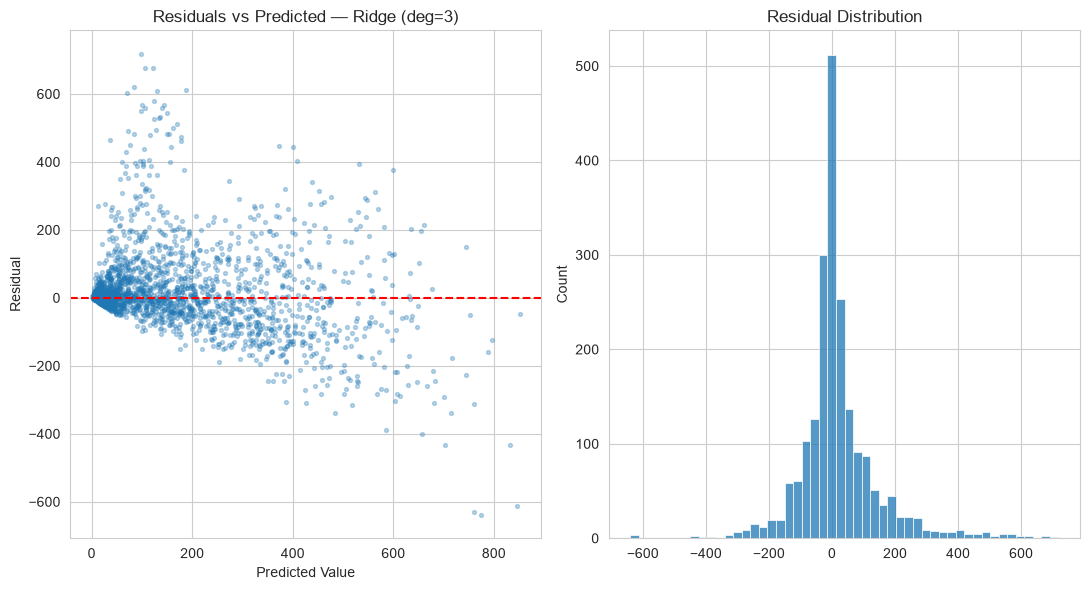

In [38]:
best_degree = int(best['Degree'])

if best['Model'] == "Linear Regression":
    best_pred_val = pred_val_cnt

else:
    if best['poly'] == None:
        best_pred_val = np.clip(np.expm1(best['fitted_model'].predict(X_val_scaled)), 0, None)
    else:
        x_val_poly_best = best['poly'].transform(x_val_scaled)
        best_pred_val = np.clip(np.expm1(best['fitted_model'].predict(x_val_poly_best)), 0, None)


residuals = y_val_cnt - best_pred_val

print("Residual mean:", round(residuals.mean(),2), "| std:", round(residuals.std(),2))

fig, axes = plt.subplots(1, 2, figsize=(11,6))
axes[0].scatter(best_pred_val, residuals, s = 8, alpha = 0.3)
axes[0].axhline(0, color = 'red', linestyle = '--')
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residuals vs Predicted — {best['Model']} (deg={best['Degree']})")

sns.histplot(residuals, bins = 50, ax = axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

## Q9 — Why does the winning model perform better?

The residual spread widens as predicted count grows (classic funnel shape) —
errors are roughly *proportional* to demand size, which is exactly what
RMSLE (a relative, log-scale metric) is built to penalize fairly, unlike raw
RMSE. The winning model does better than plain Linear Regression because (a)
it's trained directly on `log1p(count)`, matching the evaluation metric, (b)
polynomial terms let it bend around the nonlinear temperature/humidity
effects and hour pattern seen in Q2, and (c) `alpha` regularization keeps
that extra flexibility from overfitting.

## Q10 — Why does RMSLE penalize under-predictions more gently than over-predictions?

RMSLE compares `log(pred+1)` to `log(actual+1)`. Because `log` compresses
large numbers and stretches small ones, the same *absolute* miss produces a
smaller log-space gap when under-predicting than when over-predicting by the
same amount relative to a small actual value. In practice this means RMSLE
punishes wildly *large* over-predictions harder than modest under-predictions
— sensible for demand forecasting, where over-promising capacity tends to be
costlier than under-promising it.

## Q11 — Trade-offs between model simplicity and predictive power

Plain Linear Regression is simple, interpretable, fast, and low-variance —
but it can only fit straight-line, additive relationships, so it underfits
real curves like the two-peaked hourly demand pattern. Polynomial models can
fit those curves closely, but with more parameters comes higher variance
(risk of overfitting) and less interpretability. Regularization (Ridge/Lasso)
is the dial that trades these off — higher `alpha` pulls a complex model back
toward simpler, more stable behavior, and the grid search picks the `alpha`
that generalizes best on held-out validation data.

## Q12 — Why can't Linear Regression alone capture time-of-day effects effectively?

Linear Regression assumes one constant, monotonic effect per feature — a
straight line. Raw `hour` (0–23) isn't monotonic with `count`: demand rises,
dips at midday, then spikes again in the evening (Q2) — no single
coefficient on `hour` can represent that shape. On top of that, `hour` is
*cyclical* — 23:00 and 00:00 are one hour apart in reality but 23 units apart
numerically — so a linear model effectively treats midnight as the
"opposite" of 11pm. This is exactly why this notebook kept `hour` as a plain
integer for simplicity (Q4) rather than fixing it — and it's precisely the
kind of pattern the polynomial models in Q6 can approximate that plain
Linear Regression structurally cannot.

## Generating `submission.csv`

Refit the best model on **all** training data, then predict on `test`.

In [52]:
scaler_final = StandardScaler()
x_scaled_full = scaler_final.fit_transform(x)
x_scaled_test = scaler_final.transform(x_test_final)

if best['Model'] == "Linear Regression":
    final_model = LinearRegression()
    final_model.fit(x_scaled_full, y_log)
    test_pred_log = final_model.predict(x_scaled_test)

else:
    poly = PolynomialFeatures(degree=best_degree, include_bias=False)
    x_poly_full = poly.fit_transform(x_scaled_full)
    x_poly_test = poly.transform(x_scaled_test)
    finalmodel = Ridge if best['Model'] == "Ridge" else Lasso
    final_model = finalmodel(max_iter=20000, alpha = best['Alpha']) if finalmodel is Lasso else finalmodel(alpha=best['Alpha'])
    final_model.fit(x_poly_full, y_log)
    test_pred_log = final_model.predict(x_poly_test)
'''

else:
    poly = PolynomialFeatures(degree=best_degree, include_bias=False)
    x_poly_full = poly.fit_transform(x_scaled_full)
    x_poly_test = poly.transform(x_scaled_test)
    finalmodel = Ridge if best['Model'] == "Ridge" else Lasso
    final_model = finalmodel(max_iter=20000, alpha=best['Alpha']) if finalmodel is Lasso else finalmodel(alpha=best['Alpha'])
    final_model.fit(x_poly_full, y_log)
    test_pred_log = final_model.predict(x_poly_test)
'''
test_pred_cnt = np.clip(np.expm1(test_pred_log), 0, None)

submission = pd.DataFrame({'datetime': df_test['datetime'], 'count_predictde': test_pred_cnt})


assert submission.shape[0] == df_test.shape[0]
assert submission['count_predicted'].isna().sum() == 0
assert list(submission.columns) == ['datetime', 'count_predicted']

submission.to_csv('F:\ML Assignment\submission.csv', index=False)
print("Saved submission.csv —", submission.shape)
print(submission.head())

KeyError: 'count_predicted'